In [1]:
import h5py
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, LinearRegression, SGDRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF
import time
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from pathlib import Path


In [43]:
# Configuration
BASE_DIR = Path('.')                         # folder containing PDE folders; use Path('Framework2') if running from repo root
PDE_NAME = 'Param_wave'                # PDE folder to run, e.g. Conservation_law, DiffReacAdv, Nonlinear_Klein_Gordon, Param_DiffReac, Param_wave
DATA_SUBDIR = 'dataset_simple'               # subfolder inside the PDE folder that contains HDF5 files
DATA_FILENAME = 'solutions.h5'               # in-distribution HDF5 filename
OOD_FILENAME = 'ood.h5'                      # OOD HDF5 filename, used only if USE_OOD=True and the file exists
USE_OOD = False                               # if False, skip all OOD loading/evaluation/visualization

PDE_DIR = BASE_DIR / PDE_NAME                # resolved PDE folder
DATA_PATH = PDE_DIR / DATA_SUBDIR / DATA_FILENAME  # in-distribution HDF5 path
OOD_PATH = PDE_DIR / DATA_SUBDIR / OOD_FILENAME    # OOD HDF5 path
DATA_KEY = 'data'                            # HDF5 dataset key for solution arrays, shape (N, T, X, C)
COEFF_KEY = 'coeffs'                         # HDF5 dataset key for PDE coefficient/parameter arrays

TRAIN_SIZE = 10000                           # number of first samples used for training; remaining samples are test
INPUT_TIME_INDEX = 0                         # time index used as the input initial condition u(t_index, x)
CHANNEL_INDEX = 0                            # solution channel/variable index; 0 is the only valid choice if C=1

ALPHA = 1e-10                                # GPR nugget/noise regularization added to the kernel diagonal

VANILLA_RBF_LENGTH_SCALE = 100               # length scale for the vanilla RBF kernel on initial conditions
VANILLA_MATERN_LENGTH_SCALE = 100            # length scale for the vanilla Matern kernel on initial conditions
VANILLA_MATERN_NU = 3/2                      # smoothness parameter for the vanilla Matern kernel

PRODUCT_COEF_LENGTH_SCALE = 1                # length scale for the coefficient Matern kernel in the product model
PRODUCT_COEF_NU = 5/2                        # smoothness parameter for the coefficient Matern kernel
PRODUCT_STATE_LENGTH_SCALE = 100             # length scale for the initial-condition Matern kernel in the product model
PRODUCT_STATE_NU = 3/2                       # smoothness parameter for the initial-condition Matern kernel

PRODUCT_RBF_COEF_LENGTH_SCALE = 1            # length scale for the coefficient RBF kernel in the product RBF model
PRODUCT_RBF_STATE_LENGTH_SCALE = 100         # length scale for the initial-condition RBF kernel in the product RBF model

USE_PCA = False                              # master switch for PCA preprocessing
USE_X_PCA = True                             # if USE_PCA=True, reduce the initial condition u(t=0, x)
USE_COEF_PCA = True                          # if USE_PCA=True, reduce the coefficient/parameter vector for product kernels
USE_Y_PCA = True                             # if USE_PCA=True, reduce the output trajectory before learning
Y_PCA_BY_TIME = True                         # if True, fit one output PCA per time slice; otherwise fit one PCA to flattened trajectories

N_X_PCA = 5                                 # initial-condition PCA dimension
N_COEF_PCA = 4                               # coefficient PCA dimension
N_Y_PCA = 5                                 # output PCA dimension; if Y_PCA_BY_TIME=True, this is per time slice

VIS_IDX = 0                                  # sample index used in the final visualization cell
VIS_PLOT_OOD = False                         # if True, visualize OOD predictions; otherwise visualize test predictions


In [44]:
# Load data and create train/test/OOD splits
with h5py.File(DATA_PATH, 'r') as f:
    dataset = f[DATA_KEY][:]
    coef = f[COEFF_KEY][:]

print('PDE:', PDE_NAME)
print('Data path:', DATA_PATH)
print('Dataset shape:', dataset.shape)
print('Coefficient shape:', coef.shape)

testSize = dataset.shape[0] - TRAIN_SIZE
if testSize <= 0:
    raise ValueError(f'TRAIN_SIZE={TRAIN_SIZE} leaves no test samples for dataset with {dataset.shape[0]} samples.')

X_train = dataset[:TRAIN_SIZE, INPUT_TIME_INDEX, :, CHANNEL_INDEX]
Y_train = dataset[:TRAIN_SIZE, :, :, CHANNEL_INDEX]
X_test = dataset[TRAIN_SIZE:, INPUT_TIME_INDEX, :, CHANNEL_INDEX]
Y_test = dataset[TRAIN_SIZE:, :, :, CHANNEL_INDEX]
coef_train = coef[:TRAIN_SIZE]
coef_test = coef[TRAIN_SIZE:]

HAS_OOD = bool(USE_OOD and Path(OOD_PATH).exists())
if HAS_OOD:
    with h5py.File(OOD_PATH, 'r') as f_ood:
        dataset_ood = f_ood[DATA_KEY][:]
        coef_ood = f_ood[COEFF_KEY][:]

    X_ood = dataset_ood[:, INPUT_TIME_INDEX, :, CHANNEL_INDEX]
    Y_ood = dataset_ood[:, :, :, CHANNEL_INDEX]
    print('OOD path:', OOD_PATH)
else:
    dataset_ood = None
    coef_ood = None
    X_ood = None
    Y_ood = None
    if USE_OOD:
        print(f'OOD requested, but file not found: {OOD_PATH}. Skipping OOD evaluation.')
    else:
        print('OOD evaluation disabled.')

print('Train shapes:', X_train.shape, coef_train.shape, Y_train.shape)
print('Test shapes:', X_test.shape, coef_test.shape, Y_test.shape)
if HAS_OOD:
    print('OOD shapes:', X_ood.shape, coef_ood.shape, Y_ood.shape)


PDE: Param_wave
Data path: Param_wave/dataset_simple/solutions.h5
Dataset shape: (14000, 64, 128, 1)
Coefficient shape: (14000, 64)
OOD evaluation disabled.
Train shapes: (10000, 128) (10000, 64) (10000, 64, 128)
Test shapes: (4000, 128) (4000, 64) (4000, 64, 128)


In [45]:
# Optional PCA preprocessing

Y_train_flat = Y_train.reshape(Y_train.shape[0], -1)
Y_test_flat = Y_test.reshape(Y_test.shape[0], -1)
Y_ood_flat = Y_ood.reshape(Y_ood.shape[0], -1) if HAS_OOD else None

if USE_PCA and USE_X_PCA:
    n_x_components = min(N_X_PCA, X_train.shape[0], X_train.shape[1])
    x_pca = PCA(n_components=n_x_components)
    X_train_model = x_pca.fit_transform(X_train)
    X_test_model = x_pca.transform(X_test)
    X_ood_model = x_pca.transform(X_ood) if HAS_OOD else None
else:
    x_pca = None
    X_train_model = X_train
    X_test_model = X_test
    X_ood_model = X_ood if HAS_OOD else None

if USE_PCA and USE_COEF_PCA:
    n_coef_components = min(N_COEF_PCA, coef_train.shape[0], coef_train.shape[1])
    coef_pca = PCA(n_components=n_coef_components)
    coef_train_model = coef_pca.fit_transform(coef_train)
    coef_test_model = coef_pca.transform(coef_test)
    coef_ood_model = coef_pca.transform(coef_ood) if HAS_OOD else None
else:
    coef_pca = None
    coef_train_model = coef_train
    coef_test_model = coef_test
    coef_ood_model = coef_ood if HAS_OOD else None

if USE_PCA and USE_Y_PCA and Y_PCA_BY_TIME:
    y_pcas = []
    y_component_slices = []
    y_train_parts = []
    start = 0
    for t in range(Y_train.shape[1]):
        n_y_components = min(N_Y_PCA, Y_train.shape[0], Y_train.shape[2])
        pca_t = PCA(n_components=n_y_components)
        y_train_t = pca_t.fit_transform(Y_train[:, t, :])
        y_pcas.append(pca_t)
        y_train_parts.append(y_train_t)
        stop = start + n_y_components
        y_component_slices.append(slice(start, stop))
        start = stop
    Y_train_model = np.hstack(y_train_parts)

    def decode_prediction(prediction):
        prediction = np.asarray(prediction)
        decoded_times = []
        for pca_t, sl in zip(y_pcas, y_component_slices):
            decoded_times.append(pca_t.inverse_transform(prediction[:, sl]))
        return np.stack(decoded_times, axis=1)

    def decode_std(std):
        std = np.asarray(std)
        if std.ndim == 1:
            return std
        decoded_times = []
        for pca_t, sl in zip(y_pcas, y_component_slices):
            decoded_var_t = (std[:, sl]**2) @ (pca_t.components_**2)
            decoded_times.append(np.sqrt(np.maximum(decoded_var_t, 0.0)))
        return np.stack(decoded_times, axis=1)
elif USE_PCA and USE_Y_PCA:
    n_y_components = min(N_Y_PCA, Y_train_flat.shape[0], Y_train_flat.shape[1])
    y_pca = PCA(n_components=n_y_components)
    Y_train_model = y_pca.fit_transform(Y_train_flat)

    def decode_prediction(prediction):
        prediction = np.asarray(prediction)
        decoded = y_pca.inverse_transform(prediction)
        return decoded.reshape((-1,) + Y_train.shape[1:])

    def decode_std(std):
        std = np.asarray(std)
        if std.ndim == 1:
            return std
        decoded_var = (std**2) @ (y_pca.components_**2)
        return np.sqrt(np.maximum(decoded_var, 0.0)).reshape((-1,) + Y_train.shape[1:])
else:
    y_pca = None
    y_pcas = []
    Y_train_model = Y_train_flat

    def decode_prediction(prediction):
        return np.asarray(prediction).reshape((-1,) + Y_train.shape[1:])

    def decode_std(std):
        return std

pca_tag = (
    f'pca_x{X_train_model.shape[1]}_c{coef_train_model.shape[1]}_y{Y_train_model.shape[1]}'
    if USE_PCA else 'no_pca'
)
pde_tag = str(PDE_NAME).replace('/', '_').replace(' ', '_')
results_filename = f'results_{pde_tag}_{pca_tag}.csv'

print('PCA enabled:', USE_PCA)
print('X PCA enabled:', USE_PCA and USE_X_PCA)
print('Coefficient PCA enabled:', USE_PCA and USE_COEF_PCA)
print('Y PCA enabled:', USE_PCA and USE_Y_PCA)
print('Y PCA by time:', USE_PCA and USE_Y_PCA and Y_PCA_BY_TIME)
print('X model shapes:', X_train_model.shape, X_test_model.shape, X_ood_model.shape if HAS_OOD else None)
print('Coefficient model shapes:', coef_train_model.shape, coef_test_model.shape, coef_ood_model.shape if HAS_OOD else None)
print('Y train model shape:', Y_train_model.shape)

if USE_PCA and USE_X_PCA:
    x_recon = x_pca.inverse_transform(X_train_model)
    x_recon_error = np.linalg.norm(x_recon - X_train) / np.linalg.norm(X_train)
    print('X PCA explained variance:', np.sum(x_pca.explained_variance_ratio_))
    print('X train reconstruction relative error:', x_recon_error)

if USE_PCA and USE_COEF_PCA:
    coef_recon = coef_pca.inverse_transform(coef_train_model)
    coef_recon_error = np.linalg.norm(coef_recon - coef_train) / np.linalg.norm(coef_train)
    print('Coefficient PCA explained variance:', np.sum(coef_pca.explained_variance_ratio_))
    print('Coefficient train reconstruction relative error:', coef_recon_error)

if USE_PCA and USE_Y_PCA:
    y_recon = decode_prediction(Y_train_model)
    y_recon_error = np.linalg.norm(y_recon - Y_train) / np.linalg.norm(Y_train)
    if Y_PCA_BY_TIME:
        y_explained = np.mean([np.sum(pca_t.explained_variance_ratio_) for pca_t in y_pcas])
        print('Mean per-time Y PCA explained variance:', y_explained)
    else:
        print('Y PCA explained variance:', np.sum(y_pca.explained_variance_ratio_))
    print('Y train reconstruction relative error:', y_recon_error)


PCA enabled: False
X PCA enabled: False
Coefficient PCA enabled: False
Y PCA enabled: False
Y PCA by time: False
X model shapes: (10000, 128) (4000, 128) None
Coefficient model shapes: (10000, 64) (4000, 64) None
Y train model shape: (10000, 8192)


# Vanilla Kernel

In [46]:
results = []


def relative_errors(pred, target):
    return np.linalg.norm(pred - target, axis=(1, 2)) / np.linalg.norm(target, axis=(1, 2))


def sample_uncertainty(std):
    std = np.asarray(std)
    if std.ndim == 1:
        return std
    return np.sqrt(np.mean(std**2, axis=tuple(range(1, std.ndim))))


def add_result(method, kernel, split, errors, **params):
    row = {
        'pde': PDE_NAME,
        'method': method,
        'kernel': kernel,
        'split': split,
        'n_train': X_train.shape[0],
        'n_eval': len(errors),
        'mean_relative_error': float(np.mean(errors)),
        'std_relative_error': float(np.std(errors)),
        'pca': USE_PCA,
        'x_model_dim': X_train_model.shape[1],
        'coef_model_dim': coef_train_model.shape[1],
        'y_model_dim': Y_train_model.shape[1],
        'train_time_seconds': params.pop('train_time_seconds', np.nan),
        'predict_time_seconds': params.pop('predict_time_seconds', np.nan),
    }
    row.update(params)
    results.append(row)


def results_table():
    return pd.DataFrame(results)


def plot_uncertainty(name, test_uncertainty, test_error, ood_uncertainty=None):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.scatter(test_uncertainty, test_error, s=12, alpha=0.6)
    plt.xlabel('predictive std')
    plt.ylabel('relative error')
    plt.title(f'{name}: uncertainty vs error')

    plt.subplot(1, 2, 2)
    plt.hist(test_uncertainty, bins=30, alpha=0.6, label='test')
    if ood_uncertainty is not None:
        plt.hist(ood_uncertainty, bins=30, alpha=0.6, label='ood')
    plt.xlabel('predictive std')
    plt.ylabel('count')
    plt.title(f'{name}: uncertainty distribution')
    plt.legend()
    plt.tight_layout()


In [47]:
##################### RBF kernel
bandwidth = VANILLA_RBF_LENGTH_SCALE
kernel = RBF(length_scale=bandwidth)
model = GaussianProcessRegressor(kernel, alpha=ALPHA, optimizer=None)

start = time.perf_counter()
model.fit(X_train_model, Y_train_model)
rbf_train_time = time.perf_counter() - start

# prediction
start = time.perf_counter()
pred_flat, pred_std = model.predict(X_test_model, return_std=True)
rbf_test_predict_time = time.perf_counter() - start

pred = decode_prediction(pred_flat)
rbf_test_uncertainty = sample_uncertainty(decode_std(pred_std))
rbf_test_error = relative_errors(pred, Y_test)
e = np.mean(rbf_test_error)
add_result(
    'vanilla', 'RBF', 'test', rbf_test_error,
    length_scale=bandwidth, alpha=ALPHA,
    train_time_seconds=rbf_train_time,
    predict_time_seconds=rbf_test_predict_time,
)
print(f'RBF kernel: test error is {e:.2e}.')
print(f'RBF kernel: train time is {rbf_train_time:.2f}s, test predict time is {rbf_test_predict_time:.2f}s.\n')


RBF kernel: test error is 5.40e-01.
RBF kernel: train time is 13.75s, test predict time is 3.12s.



RBF kernel: OOD evaluation skipped.



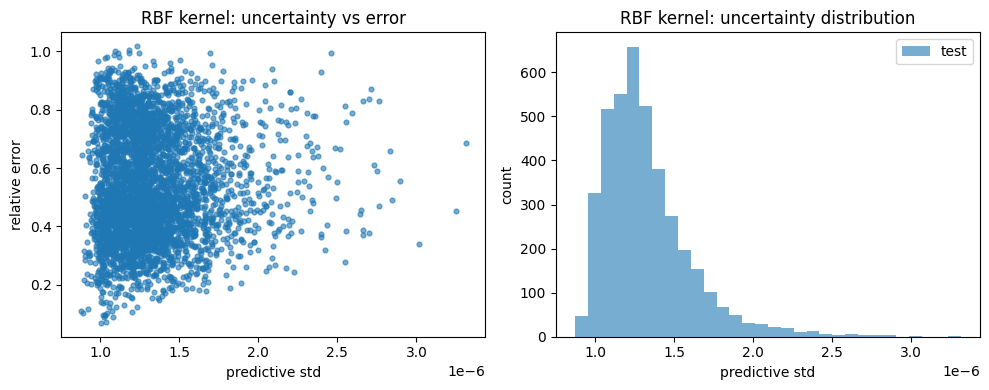

In [48]:
### out-of-distribution testing
if HAS_OOD:
    start = time.perf_counter()
    ood_pred_flat, ood_pred_std = model.predict(X_ood_model, return_std=True)
    rbf_ood_predict_time = time.perf_counter() - start

    ood_pred = decode_prediction(ood_pred_flat)
    rbf_ood_uncertainty = sample_uncertainty(decode_std(ood_pred_std))
    rbf_ood_error = relative_errors(ood_pred, Y_ood)
    ood_e = np.mean(rbf_ood_error)
    add_result(
        'vanilla', 'RBF', 'ood', rbf_ood_error,
        length_scale=bandwidth, alpha=ALPHA,
        train_time_seconds=rbf_train_time,
        predict_time_seconds=rbf_ood_predict_time,
    )
    print(f'RBF kernel: out-of-distribution error is {ood_e:.2e}.')
    print(f'RBF kernel: OOD predict time is {rbf_ood_predict_time:.2f}s.\n')
else:
    rbf_ood_uncertainty = None
    print('RBF kernel: OOD evaluation skipped.\n')

plot_uncertainty('RBF kernel', rbf_test_uncertainty, rbf_test_error, rbf_ood_uncertainty)


Matern kernel: test error is 8.32e-01.
Matern kernel: train time is 13.91s, test predict time is 3.17s.

Matern kernel: OOD evaluation skipped.



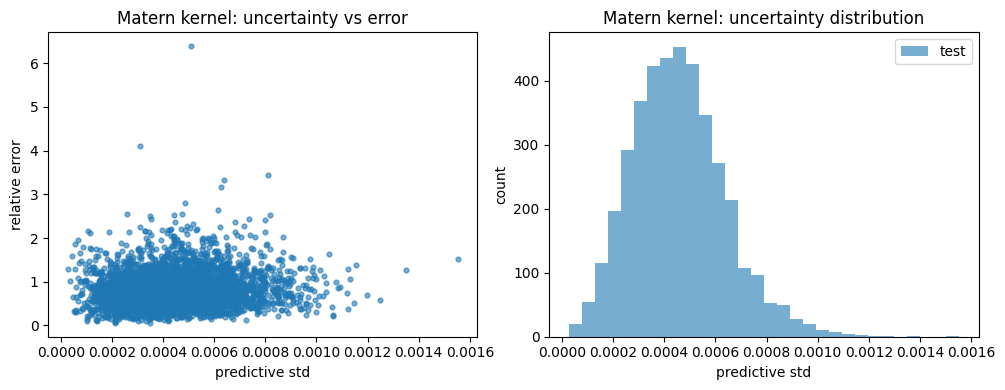

In [49]:
##################### Matern kernel
bandwidth = VANILLA_MATERN_LENGTH_SCALE
nu = VANILLA_MATERN_NU
kernel = Matern(length_scale=bandwidth, nu=nu)
model = GaussianProcessRegressor(kernel, alpha=ALPHA, optimizer=None)

start = time.perf_counter()
model.fit(X_train_model, Y_train_model)
matern_train_time = time.perf_counter() - start

# prediction
start = time.perf_counter()
matern_pred_flat, matern_pred_std = model.predict(X_test_model, return_std=True)
matern_test_predict_time = time.perf_counter() - start

matern_pred = decode_prediction(matern_pred_flat)
matern_test_uncertainty = sample_uncertainty(decode_std(matern_pred_std))
matern_test_error = relative_errors(matern_pred, Y_test)
matern_e = np.mean(matern_test_error)
add_result(
    'vanilla', 'Matern', 'test', matern_test_error,
    length_scale=bandwidth, nu=nu, alpha=ALPHA,
    train_time_seconds=matern_train_time,
    predict_time_seconds=matern_test_predict_time,
)
print(f'Matern kernel: test error is {matern_e:.2e}.')
print(f'Matern kernel: train time is {matern_train_time:.2f}s, test predict time is {matern_test_predict_time:.2f}s.\n')

### out-of-distribution testing
if HAS_OOD:
    start = time.perf_counter()
    matern_ood_pred_flat, matern_ood_pred_std = model.predict(X_ood_model, return_std=True)
    matern_ood_predict_time = time.perf_counter() - start

    matern_ood_pred = decode_prediction(matern_ood_pred_flat)
    matern_ood_uncertainty = sample_uncertainty(decode_std(matern_ood_pred_std))
    matern_ood_error = relative_errors(matern_ood_pred, Y_ood)
    matern_ood_e = np.mean(matern_ood_error)
    add_result(
        'vanilla', 'Matern', 'ood', matern_ood_error,
        length_scale=bandwidth, nu=nu, alpha=ALPHA,
        train_time_seconds=matern_train_time,
        predict_time_seconds=matern_ood_predict_time,
    )
    print(f'Matern kernel: out-of-distribution error is {matern_ood_e:.2e}.')
    print(f'Matern kernel: OOD predict time is {matern_ood_predict_time:.2f}s.\n')
else:
    matern_ood_uncertainty = None
    print('Matern kernel: OOD evaluation skipped.\n')

plot_uncertainty('Matern kernel', matern_test_uncertainty, matern_test_error, matern_ood_uncertainty)


In [50]:
results_df = results_table()
display(results_df)

results_df


,pde,method,kernel,split,n_train,n_eval,mean_relative_error,std_relative_error,pca,x_model_dim,coef_model_dim,y_model_dim,train_time_seconds,predict_time_seconds,length_scale,alpha,nu
0,Param_wave,vanilla,RBF,test,10000,4000,0.540277,0.187605,False,128,64,8192,13.751708,3.120959,100,1.000000e-10,NaN
1,Param_wave,vanilla,Matern,test,10000,4000,0.831625,0.402569,False,128,64,8192,13.907714,3.170400,100,1.000000e-10,1.5


,pde,method,kernel,split,n_train,n_eval,mean_relative_error,std_relative_error,pca,x_model_dim,coef_model_dim,y_model_dim,train_time_seconds,predict_time_seconds,length_scale,alpha,nu
0,Param_wave,vanilla,RBF,test,10000,4000,0.540277,0.187605,False,128,64,8192,13.751708,3.120959,100,1.000000e-10,NaN
1,Param_wave,vanilla,Matern,test,10000,4000,0.831625,0.402569,False,128,64,8192,13.907714,3.170400,100,1.000000e-10,1.5


# Our Method

Product GPR: test error is 3.35e-02.
Product GPR: train time is 16.18s, test predict time is 3.96s.

Product GPR: OOD evaluation skipped.



,pde,method,kernel,split,n_train,n_eval,mean_relative_error,std_relative_error,pca,x_model_dim,...,y_model_dim,train_time_seconds,predict_time_seconds,length_scale,alpha,nu,coef_length_scale,coef_nu,state_length_scale,state_nu
0,Param_wave,vanilla,RBF,test,10000,4000,0.540277,0.187605,False,128,...,8192,13.751708,3.120959,100.0,1.000000e-10,NaN,NaN,NaN,NaN,NaN
1,Param_wave,vanilla,Matern,test,10000,4000,0.831625,0.402569,False,128,...,8192,13.907714,3.170400,100.0,1.000000e-10,1.5,NaN,NaN,NaN,NaN
2,Param_wave,product_gpr,Matern x Matern,test,10000,4000,0.033457,0.067757,False,128,...,8192,16.183660,3.957850,NaN,1.000000e-10,NaN,1.0,2.5,100.0,1.5


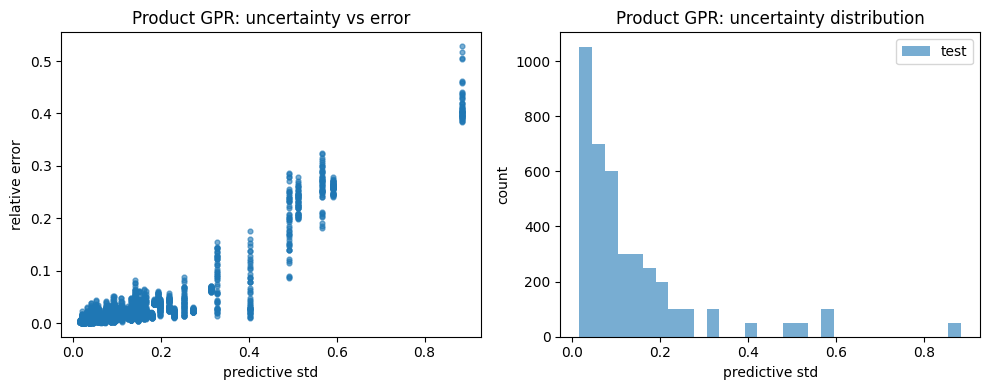

In [51]:
from sklearn.gaussian_process.kernels import Kernel


class ProductPDEKernel(Kernel):
    def __init__(self, n_u, coef_kernel=None, state_kernel=None):
        self.n_u = n_u
        self.coef_kernel = coef_kernel
        self.state_kernel = state_kernel

    def __call__(self, X, Y=None, eval_gradient=False):
        if eval_gradient:
            raise ValueError('Gradient is not implemented. Use optimizer=None.')

        X_u = X[:, :self.n_u]
        X_c = X[:, self.n_u:]

        if Y is None:
            Y_u = None
            Y_c = None
        else:
            Y_u = Y[:, :self.n_u]
            Y_c = Y[:, self.n_u:]

        return self.state_kernel(X_u, Y_u) * self.coef_kernel(X_c, Y_c)

    def diag(self, X):
        X_u = X[:, :self.n_u]
        X_c = X[:, self.n_u:]
        return self.state_kernel.diag(X_u) * self.coef_kernel.diag(X_c)

    def is_stationary(self):
        return self.state_kernel.is_stationary() and self.coef_kernel.is_stationary()


##################### Our method with GaussianProcessRegressor
coef_bandwidth = PRODUCT_COEF_LENGTH_SCALE
coef_nu = PRODUCT_COEF_NU
state_bandwidth = PRODUCT_STATE_LENGTH_SCALE
state_nu = PRODUCT_STATE_NU

product_kernel = ProductPDEKernel(
    n_u=X_train_model.shape[1],
    coef_kernel=Matern(length_scale=coef_bandwidth, nu=coef_nu),
    state_kernel=Matern(length_scale=state_bandwidth, nu=state_nu),
)

X_train_product = np.hstack([X_train_model, coef_train_model])
X_test_product = np.hstack([X_test_model, coef_test_model])
X_ood_product = np.hstack([X_ood_model, coef_ood_model]) if HAS_OOD else None

model = GaussianProcessRegressor(product_kernel, alpha=ALPHA, optimizer=None)

start = time.perf_counter()
model.fit(X_train_product, Y_train_model)
product_train_time = time.perf_counter() - start

# prediction
start = time.perf_counter()
product_pred_flat, product_pred_std = model.predict(X_test_product, return_std=True)
product_test_predict_time = time.perf_counter() - start
product_pred = decode_prediction(product_pred_flat)
product_test_uncertainty = sample_uncertainty(decode_std(product_pred_std))
product_test_error = relative_errors(product_pred, Y_test)
product_e = np.mean(product_test_error)
add_result(
    'product_gpr',
    'Matern x Matern',
    'test',
    product_test_error,
    coef_length_scale=coef_bandwidth,
    coef_nu=coef_nu,
    state_length_scale=state_bandwidth,
    state_nu=state_nu,
    alpha=ALPHA,
    train_time_seconds=product_train_time,
    predict_time_seconds=product_test_predict_time,
)
print(f'Product GPR: test error is {product_e:.2e}.')
print(f'Product GPR: train time is {product_train_time:.2f}s, test predict time is {product_test_predict_time:.2f}s.\n')

### out-of-distribution testing
if HAS_OOD:
    start = time.perf_counter()
    product_ood_pred_flat, product_ood_pred_std = model.predict(X_ood_product, return_std=True)
    product_ood_predict_time = time.perf_counter() - start
    product_ood_pred = decode_prediction(product_ood_pred_flat)
    product_ood_uncertainty = sample_uncertainty(decode_std(product_ood_pred_std))
    product_ood_error = relative_errors(product_ood_pred, Y_ood)
    product_ood_e = np.mean(product_ood_error)
    add_result(
        'product_gpr',
        'Matern x Matern',
        'ood',
        product_ood_error,
        coef_length_scale=coef_bandwidth,
        coef_nu=coef_nu,
        state_length_scale=state_bandwidth,
        state_nu=state_nu,
        alpha=ALPHA,
        train_time_seconds=product_train_time,
        predict_time_seconds=product_ood_predict_time,
    )
    print(f'Product GPR: out-of-distribution error is {product_ood_e:.2e}.')
    print(f'Product GPR: OOD predict time is {product_ood_predict_time:.2f}s.\n')
else:
    product_ood_uncertainty = None
    print('Product GPR: OOD evaluation skipped.\n')

plot_uncertainty('Product GPR', product_test_uncertainty, product_test_error, product_ood_uncertainty)

results_df = results_table()
display(results_df)
results_df.to_csv(results_filename, index=False)


Product RBF GPR: test error is 5.43e-02.
Product RBF GPR: train time is 15.92s, test predict time is 3.90s.

Product RBF GPR: OOD evaluation skipped.



,pde,method,kernel,split,n_train,n_eval,mean_relative_error,std_relative_error,pca,x_model_dim,...,y_model_dim,train_time_seconds,predict_time_seconds,length_scale,alpha,nu,coef_length_scale,coef_nu,state_length_scale,state_nu
0,Param_wave,vanilla,RBF,test,10000,4000,0.540277,0.187605,False,128,...,8192,13.751708,3.120959,100.0,1.000000e-10,NaN,NaN,NaN,NaN,NaN
1,Param_wave,vanilla,Matern,test,10000,4000,0.831625,0.402569,False,128,...,8192,13.907714,3.170400,100.0,1.000000e-10,1.5,NaN,NaN,NaN,NaN
2,Param_wave,product_gpr,Matern x Matern,test,10000,4000,0.033457,0.067757,False,128,...,8192,16.183660,3.957850,NaN,1.000000e-10,NaN,1.0,2.5,100.0,1.5
3,Param_wave,product_gpr,RBF x RBF,test,10000,4000,0.054332,0.102123,False,128,...,8192,15.919035,3.899901,NaN,1.000000e-10,NaN,1.0,NaN,100.0,NaN


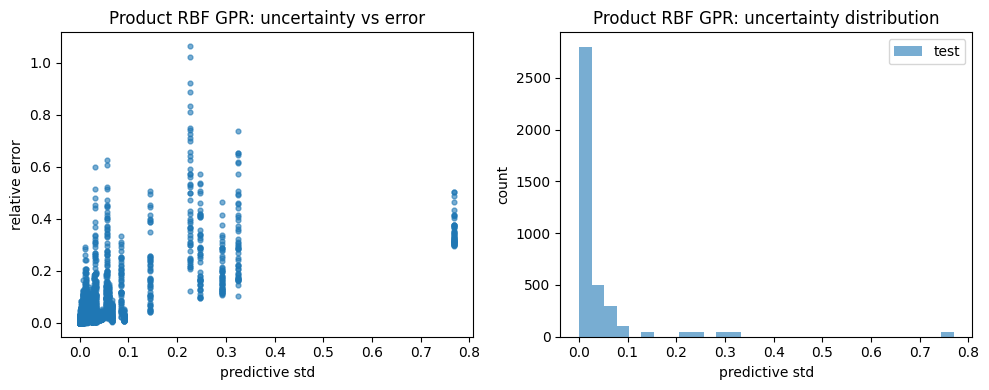

In [52]:
##################### Product RBF with GaussianProcessRegressor
coef_bandwidth = PRODUCT_RBF_COEF_LENGTH_SCALE
state_bandwidth = PRODUCT_RBF_STATE_LENGTH_SCALE

product_rbf_kernel = ProductPDEKernel(
    n_u=X_train_model.shape[1],
    coef_kernel=RBF(length_scale=coef_bandwidth),
    state_kernel=RBF(length_scale=state_bandwidth),
)

X_train_product = np.hstack([X_train_model, coef_train_model])
X_test_product = np.hstack([X_test_model, coef_test_model])
X_ood_product = np.hstack([X_ood_model, coef_ood_model]) if HAS_OOD else None

model = GaussianProcessRegressor(product_rbf_kernel, alpha=ALPHA, optimizer=None)

start = time.perf_counter()
model.fit(X_train_product, Y_train_model)
product_rbf_train_time = time.perf_counter() - start

# prediction
start = time.perf_counter()
product_rbf_pred_flat, product_rbf_pred_std = model.predict(X_test_product, return_std=True)
product_rbf_test_predict_time = time.perf_counter() - start
product_rbf_pred = decode_prediction(product_rbf_pred_flat)
product_rbf_test_uncertainty = sample_uncertainty(decode_std(product_rbf_pred_std))
product_rbf_test_error = relative_errors(product_rbf_pred, Y_test)
product_rbf_e = np.mean(product_rbf_test_error)
add_result(
    'product_gpr',
    'RBF x RBF',
    'test',
    product_rbf_test_error,
    coef_length_scale=coef_bandwidth,
    state_length_scale=state_bandwidth,
    alpha=ALPHA,
    train_time_seconds=product_rbf_train_time,
    predict_time_seconds=product_rbf_test_predict_time,
)
print(f'Product RBF GPR: test error is {product_rbf_e:.2e}.')
print(f'Product RBF GPR: train time is {product_rbf_train_time:.2f}s, test predict time is {product_rbf_test_predict_time:.2f}s.\n')

### out-of-distribution testing
if HAS_OOD:
    start = time.perf_counter()
    product_rbf_ood_pred_flat, product_rbf_ood_pred_std = model.predict(X_ood_product, return_std=True)
    product_rbf_ood_predict_time = time.perf_counter() - start
    product_rbf_ood_pred = decode_prediction(product_rbf_ood_pred_flat)
    product_rbf_ood_uncertainty = sample_uncertainty(decode_std(product_rbf_ood_pred_std))
    product_rbf_ood_error = relative_errors(product_rbf_ood_pred, Y_ood)
    product_rbf_ood_e = np.mean(product_rbf_ood_error)
    add_result(
        'product_gpr',
        'RBF x RBF',
        'ood',
        product_rbf_ood_error,
        coef_length_scale=coef_bandwidth,
        state_length_scale=state_bandwidth,
        alpha=ALPHA,
        train_time_seconds=product_rbf_train_time,
        predict_time_seconds=product_rbf_ood_predict_time,
    )
    print(f'Product RBF GPR: out-of-distribution error is {product_rbf_ood_e:.2e}.')
    print(f'Product RBF GPR: OOD predict time is {product_rbf_ood_predict_time:.2f}s.\n')
else:
    product_rbf_ood_uncertainty = None
    print('Product RBF GPR: OOD evaluation skipped.\n')

plot_uncertainty('Product RBF GPR', product_rbf_test_uncertainty, product_rbf_test_error, product_rbf_ood_uncertainty)

results_df = results_table()
display(results_df)
results_df.to_csv(results_filename, index=False)


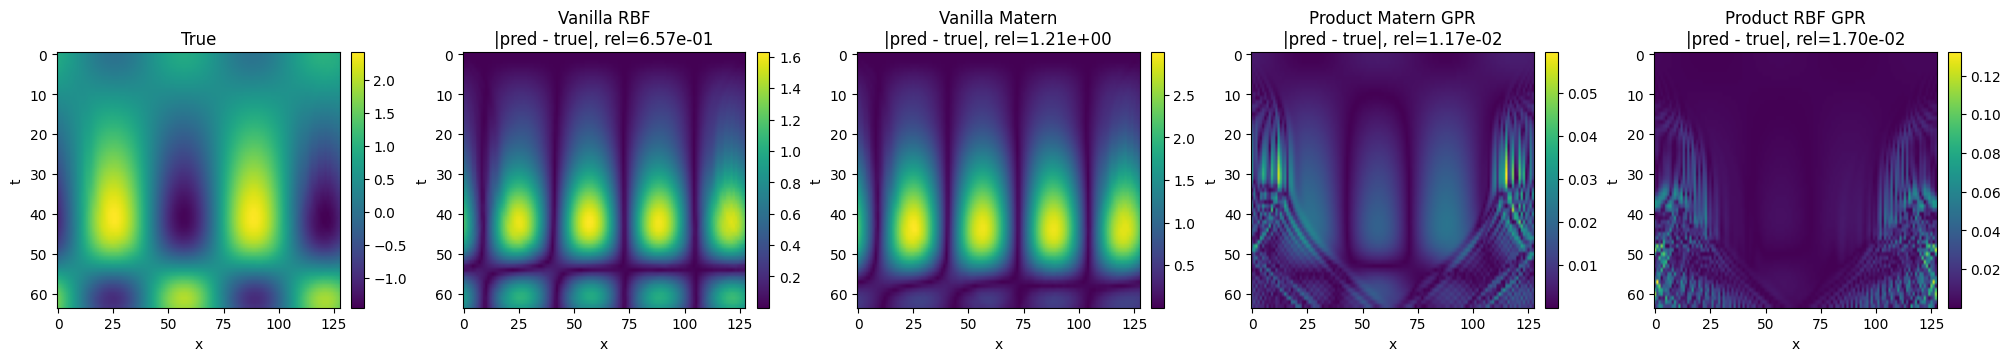

In [53]:
# visualization: true trajectory and prediction errors
idx = VIS_IDX
plot_ood = VIS_PLOT_OOD

if plot_ood and not HAS_OOD:
    raise ValueError('VIS_PLOT_OOD=True, but OOD evaluation is disabled or OOD file is unavailable.')

if plot_ood:
    target = Y_ood[idx]
    prediction_candidates = {
        'Vanilla RBF': globals().get('ood_pred'),
        'Vanilla Matern': globals().get('matern_ood_pred'),
        'Product Matern GPR': globals().get('product_ood_pred'),
        'Product RBF GPR': globals().get('product_rbf_ood_pred'),
    }
else:
    target = Y_test[idx]
    prediction_candidates = {
        'Vanilla RBF': globals().get('pred'),
        'Vanilla Matern': globals().get('matern_pred'),
        'Product Matern GPR': globals().get('product_pred'),
        'Product RBF GPR': globals().get('product_rbf_pred'),
    }

predictions = {
    name: values[idx]
    for name, values in prediction_candidates.items()
    if values is not None
}

n_cols = len(predictions) + 1
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 3.5), constrained_layout=True)
if n_cols == 1:
    axes = [axes]

true_im = axes[0].imshow(target, aspect='auto')
axes[0].set_title('True')
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
fig.colorbar(true_im, ax=axes[0], fraction=0.046, pad=0.04)

for ax, (name, prediction) in zip(axes[1:], predictions.items()):
    error = np.abs(prediction - target)
    im = ax.imshow(error, aspect='auto')
    rel_error = np.linalg.norm(prediction - target) / np.linalg.norm(target)
    ax.set_title(f'{name}\n|pred - true|, rel={rel_error:.2e}')
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()


In [54]:
import pandas as pd
from IPython.display import display

def load_results_csv(path):
    df = pd.read_csv(path)
    display(df)
    return df

df = load_results_csv(results_filename)

,pde,method,kernel,split,n_train,n_eval,mean_relative_error,std_relative_error,pca,x_model_dim,...,y_model_dim,train_time_seconds,predict_time_seconds,length_scale,alpha,nu,coef_length_scale,coef_nu,state_length_scale,state_nu
0,Param_wave,vanilla,RBF,test,10000,4000,0.540277,0.187605,False,128,...,8192,13.751708,3.120959,100.0,1.000000e-10,NaN,NaN,NaN,NaN,NaN
1,Param_wave,vanilla,Matern,test,10000,4000,0.831625,0.402569,False,128,...,8192,13.907714,3.170400,100.0,1.000000e-10,1.5,NaN,NaN,NaN,NaN
2,Param_wave,product_gpr,Matern x Matern,test,10000,4000,0.033457,0.067757,False,128,...,8192,16.183660,3.957850,NaN,1.000000e-10,NaN,1.0,2.5,100.0,1.5
3,Param_wave,product_gpr,RBF x RBF,test,10000,4000,0.054332,0.102123,False,128,...,8192,15.919035,3.899901,NaN,1.000000e-10,NaN,1.0,NaN,100.0,NaN
